# Task 2 — Classical Image Features and Numbers-First LLM Interpretation

This notebook performs the classical image-analysis stage of the project.

The workflow is:

**Grayscale image → Otsu thresholding → morphological cleanup → connected components → regionprops features → numerical summary → local LLM interpretation**

The LLM receives the numerical measurements only; it does not receive the image. This allows the language-model interpretation to be compared with the direct visual description produced in Task 1.

The notebook also compares the classical Otsu segmentation with the already-trained U-Net using the existing model outputs, without retraining the U-Net.

## 1. Setup and Project Paths

The project uses the existing dataset and output structure established in the previous notebooks. No model training is performed here.

The notebook creates a dedicated output directory for the classical post-processing results.

In [16]:
# ============================================================
# CELL 3 — IMPORTS AND PROJECT PATHS
# ============================================================

import os
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from skimage import io, measure, morphology
from skimage.filters import threshold_otsu
from skimage.morphology import (
    remove_small_objects,
    remove_small_holes,
    binary_opening,
    binary_closing,
    disk
)
from skimage.measure import label, regionprops_table

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = (
    r"C:\Users\gms\OneDrive - University of Hertfordshire"
    r"\Data Analysis with AI\Assingnment 3"
)

DATASET_ROOT = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw",
    "nuclei_dataset"
)

TRAIN_IMAGE_DIR = os.path.join(
    DATASET_ROOT,
    "train",
    "images"
)

TRAIN_MASK_DIR = os.path.join(
    DATASET_ROOT,
    "train",
    "masks"
)

TEST_IMAGE_DIR = os.path.join(
    DATASET_ROOT,
    "test",
    "images"
)

TEST_MASK_DIR = os.path.join(
    DATASET_ROOT,
    "test",
    "masks"
)

HYBRID_OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "hybrid_pipeline"
)

CLASSICAL_OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "classical_features"
)

os.makedirs(
    CLASSICAL_OUTPUT_DIR,
    exist_ok=True
)

print("=" * 70)
print("TASK 2 — CLASSICAL POST-PROCESSING SETUP")
print("=" * 70)

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATASET_ROOT)
print("Test images  :", TEST_IMAGE_DIR)
print("Test masks   :", TEST_MASK_DIR)
print("Output dir   :", CLASSICAL_OUTPUT_DIR)

TASK 2 — CLASSICAL POST-PROCESSING SETUP
Project root : C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3
Dataset root : C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset
Test images  : C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset\test\images
Test masks   : C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset\test\masks
Output dir   : C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\classical_features


In [17]:
# ============================================================
# CELL 4 — VERIFY DATASET
# ============================================================

print("=" * 70)
print("DATASET VERIFICATION")
print("=" * 70)

print(
    "Dataset exists      :",
    os.path.exists(DATASET_ROOT)
)

print(
    "Train images exist  :",
    os.path.exists(TRAIN_IMAGE_DIR)
)

print(
    "Train masks exist   :",
    os.path.exists(TRAIN_MASK_DIR)
)

print(
    "Test images exist   :",
    os.path.exists(TEST_IMAGE_DIR)
)

print(
    "Test masks exist    :",
    os.path.exists(TEST_MASK_DIR)
)


if not os.path.exists(TRAIN_IMAGE_DIR):
    raise FileNotFoundError(
        f"Training image directory not found:\n{TRAIN_IMAGE_DIR}"
    )

train_image_files = sorted([
    f for f in os.listdir(TRAIN_IMAGE_DIR)
    if f.lower().endswith(
        (".png", ".jpg", ".jpeg", ".tif", ".tiff")
    )
])

print(
    "\nNumber of training images:",
    len(train_image_files)
)

print(
    "First training images:"
)

for filename in train_image_files[:5]:
    print(" ", filename)

DATASET VERIFICATION
Dataset exists      : True
Train images exist  : True
Train masks exist   : True
Test images exist   : True
Test masks exist    : True

Number of training images: 80
First training images:
  train_000.png
  train_001.png
  train_002.png
  train_003.png
  train_004.png


## 2. Load a Representative Image

A representative image is selected from the dataset for demonstrating the complete classical segmentation process.

The same preprocessing logic is then packaged into reusable functions so that it can be applied consistently to multiple images.

REPRESENTATIVE IMAGE
Image: train_000.png
Shape: (256, 256)
Data type: float32
Intensity range: 0.0000 → 0.3468


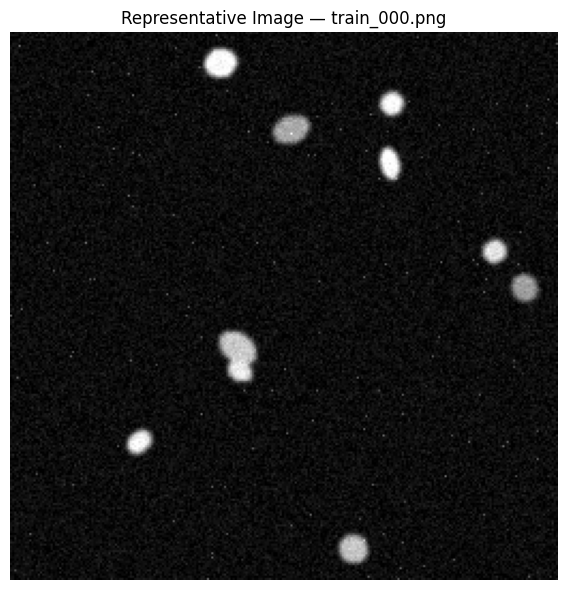

Saved: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\classical_features\representative_classical_input.png


In [18]:
# ============================================================
# CELL 6 — LOAD REPRESENTATIVE IMAGE
# ============================================================

if len(train_image_files) == 0:
    raise RuntimeError(
        "No training images were found."
    )

REPRESENTATIVE_IMAGE_ID = train_image_files[0]

representative_path = os.path.join(
    TRAIN_IMAGE_DIR,
    REPRESENTATIVE_IMAGE_ID
)

representative_image = io.imread(
    representative_path,
    as_gray=True
).astype(
    np.float32
)

# Normalise if required
if representative_image.max() > 1:
    representative_image = (
        representative_image
        / representative_image.max()
    )

print("=" * 70)
print("REPRESENTATIVE IMAGE")
print("=" * 70)

print(
    "Image:",
    REPRESENTATIVE_IMAGE_ID
)

print(
    "Shape:",
    representative_image.shape
)

print(
    "Data type:",
    representative_image.dtype
)

print(
    "Intensity range:",
    f"{representative_image.min():.4f}",
    "→",
    f"{representative_image.max():.4f}"
)


plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    representative_image,
    cmap="gray"
)

plt.title(
    f"Representative Image — {REPRESENTATIVE_IMAGE_ID}"
)

plt.axis("off")

plt.tight_layout()

representative_display_path = os.path.join(
    CLASSICAL_OUTPUT_DIR,
    "representative_classical_input.png"
)

plt.savefig(
    representative_display_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    representative_display_path
)

## 3. Otsu Thresholding and Morphological Cleanup

Otsu's method provides an automatic intensity threshold for separating foreground objects from the background.

The resulting binary mask is cleaned using morphological operations and removal of very small regions. The purpose is to reduce isolated noise and fill small gaps before connected components are measured.

The parameters are kept deliberately simple so that the classical baseline remains interpretable and reproducible.

In [19]:
# ============================================================
# CELL 8 — CLASSICAL SEGMENTATION FUNCTION
# ============================================================

def otsu_segment(
    image,
    min_object_size=20,
    min_hole_size=20,
    morphology_radius=1
):
    """
    Segment a grayscale image using Otsu thresholding
    followed by simple morphological cleanup.

    Parameters
    ----------
    image : np.ndarray
        Normalised grayscale image.

    min_object_size : int
        Minimum connected foreground size retained.

    min_hole_size : int
        Minimum hole size filled.

    morphology_radius : int
        Radius of the disk used for opening/closing.

    Returns
    -------
    threshold : float
        Otsu threshold.

    raw_mask : np.ndarray
        Binary Otsu mask before cleanup.

    clean_mask : np.ndarray
        Binary mask after morphological cleanup.
    """

    threshold = threshold_otsu(
        image
    )

    raw_mask = (
        image > threshold
    )

    structure = disk(
        morphology_radius
    )

    clean_mask = binary_opening(
        raw_mask,
        structure
    )

    clean_mask = binary_closing(
        clean_mask,
        structure
    )

    clean_mask = remove_small_objects(
        clean_mask,
        min_size=min_object_size
    )

    clean_mask = remove_small_holes(
        clean_mask,
        area_threshold=min_hole_size
    )

    return (
        threshold,
        raw_mask,
        clean_mask
    )

In [20]:
# ============================================================
# CELL 9 — RUN OTSU SEGMENTATION
# ============================================================

(
    representative_threshold,
    representative_raw_mask,
    representative_clean_mask
) = otsu_segment(
    representative_image
)

print("=" * 70)
print("OTSU SEGMENTATION")
print("=" * 70)

print(
    "Otsu threshold:",
    f"{representative_threshold:.6f}"
)

print(
    "Raw foreground pixels:",
    int(
        representative_raw_mask.sum()
    )
)

print(
    "Clean foreground pixels:",
    int(
        representative_clean_mask.sum()
    )
)

print(
    "Clean foreground fraction:",
    f"{representative_clean_mask.mean():.4%}"
)

OTSU SEGMENTATION
Otsu threshold: 0.136142
Raw foreground pixels: 1322
Clean foreground pixels: 1282
Clean foreground fraction: 1.9562%


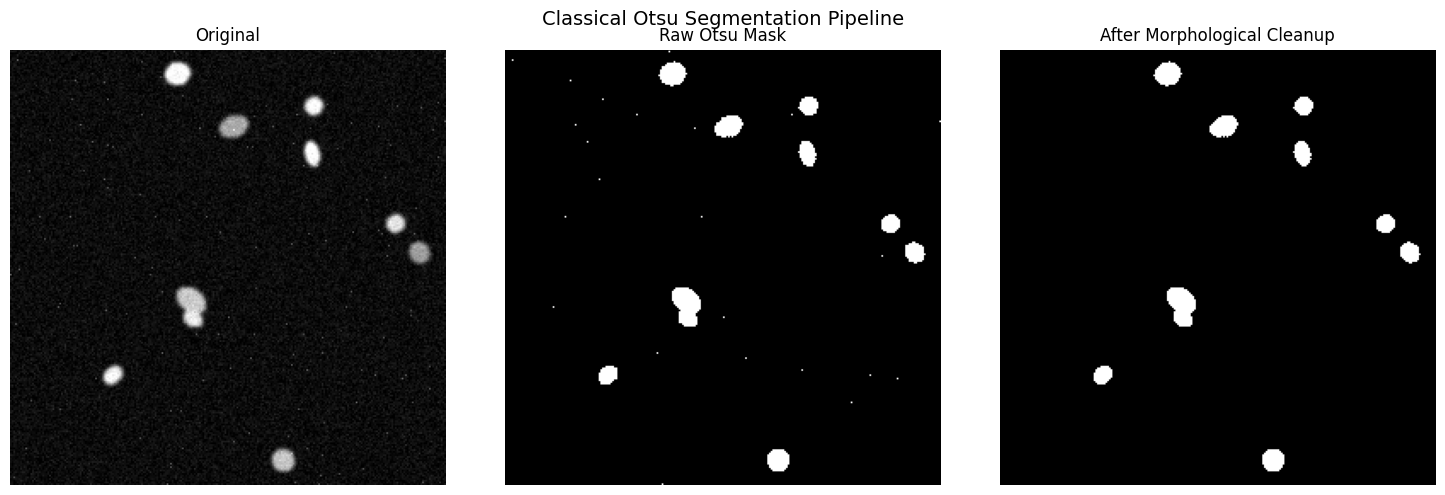

Saved: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\classical_features\otsu_segmentation_process.png


In [21]:
# ============================================================
# CELL 10 — OTSU PROCESS VISUALISATION
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    representative_image,
    cmap="gray"
)

axes[0].set_title(
    "Original"
)

axes[0].axis("off")


axes[1].imshow(
    representative_raw_mask,
    cmap="gray"
)

axes[1].set_title(
    "Raw Otsu Mask"
)

axes[1].axis("off")


axes[2].imshow(
    representative_clean_mask,
    cmap="gray"
)

axes[2].set_title(
    "After Morphological Cleanup"
)

axes[2].axis("off")


plt.suptitle(
    "Classical Otsu Segmentation Pipeline",
    fontsize=14
)

plt.tight_layout()

otsu_visual_path = os.path.join(
    CLASSICAL_OUTPUT_DIR,
    "otsu_segmentation_process.png"
)

plt.savefig(
    otsu_visual_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    otsu_visual_path
)

## 4. Connected Components and Region Properties

The cleaned Otsu mask is labelled into connected components, where each component represents a candidate foreground object.

`regionprops_table` is then used to calculate object-level measurements including area, eccentricity, solidity, perimeter, extent, and mean intensity. These measurements form the classical feature table required for Task 2.

In [22]:
# ============================================================
# CELL 12 — CONNECTED COMPONENTS AND REGIONPROPS TABLE
# ============================================================

def extract_region_features(
    image,
    binary_mask
):
    """
    Label connected foreground components and calculate
    object-level region properties.
    """

    labelled_mask = label(
        binary_mask,
        connectivity=2
    )

    properties = [
        "label",
        "area",
        "eccentricity",
        "solidity",
        "extent",
        "perimeter",
        "mean_intensity",
        "bbox"
    ]

    props = regionprops_table(
        labelled_mask,
        intensity_image=image,
        properties=properties
    )

    props_df = pd.DataFrame(
        props
    )

    return (
        labelled_mask,
        props_df
    )


(
    representative_labels,
    representative_features
) = extract_region_features(
    representative_image,
    representative_clean_mask
)

print("=" * 70)
print("REGIONPROPS FEATURE TABLE")
print("=" * 70)

print(
    "Number of detected objects:",
    len(representative_features)
)

display(
    representative_features
)

REGIONPROPS FEATURE TABLE
Number of detected objects: 9


,label,area,eccentricity,solidity,extent,perimeter,mean_intensity,bbox-0,bbox-1,bbox-2,bbox-3
0,1,171.0,0.476409,0.939560,0.670588,47.698485,0.298995,7,90,22,107
1,2,97.0,0.212625,0.979798,0.734848,33.798990,0.286278,28,172,39,184
2,3,164.0,0.702809,0.953488,0.742081,47.698485,0.213101,39,123,52,140
3,4,115.0,0.774863,0.934959,0.696970,40.041631,0.287161,54,172,69,183
4,5,98.0,0.331551,0.980000,0.809917,33.556349,0.261829,97,221,108,232
5,6,112.0,0.474086,0.933333,0.717949,37.798990,0.197504,113,235,126,247
6,7,285.0,0.798339,0.919355,0.728900,67.112698,0.260376,140,98,163,115
7,8,97.0,0.583608,0.979798,0.801653,33.556349,0.280607,186,55,197,66
8,9,143.0,0.180389,0.986207,0.846154,40.970563,0.237050,235,154,248,167


In [23]:
# ============================================================
# CELL 13 — SAVE REPRESENTATIVE FEATURE TABLE
# ============================================================

representative_feature_path = os.path.join(
    CLASSICAL_OUTPUT_DIR,
    "representative_regionprops_table.csv"
)

representative_features.to_csv(
    representative_feature_path,
    index=False
)

print(
    "Saved:",
    representative_feature_path
)

Saved: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\classical_features\representative_regionprops_table.csv


## 5. Convert Object Features into a Numerical Summary

The per-object feature table is reduced to an image-level summary. This preserves the main quantitative information while producing a compact representation that can be passed to a text-only LLM.

The summary contains object count, typical object size and shape, segmentation fraction, and intensity statistics. No image pixels are provided to the LLM at this stage.

In [24]:
# ============================================================
# CELL 15 — IMAGE-LEVEL NUMERICAL SUMMARY
# ============================================================

def create_numerical_summary(
    image_id,
    image,
    feature_table,
    binary_mask
):
    """
    Convert a regionprops feature table into a compact,
    image-level numerical summary.
    """

    n_objects = len(
        feature_table
    )

    if n_objects == 0:

        return {
            "image_id": image_id,
            "n_objects": 0,
            "mean_area": 0.0,
            "median_area": 0.0,
            "mean_eccentricity": 0.0,
            "mean_solidity": 0.0,
            "mean_extent": 0.0,
            "mean_perimeter": 0.0,
            "mean_intensity": 0.0,
            "foreground_fraction": float(
                binary_mask.mean()
            )
        }

    return {
        "image_id": image_id,
        "n_objects": int(
            n_objects
        ),
        "mean_area": float(
            feature_table["area"].mean()
        ),
        "median_area": float(
            feature_table["area"].median()
        ),
        "mean_eccentricity": float(
            feature_table["eccentricity"].mean()
        ),
        "mean_solidity": float(
            feature_table["solidity"].mean()
        ),
        "mean_extent": float(
            feature_table["extent"].mean()
        ),
        "mean_perimeter": float(
            feature_table["perimeter"].mean()
        ),
        "mean_intensity": float(
            feature_table["mean_intensity"].mean()
        ),
        "foreground_fraction": float(
            binary_mask.mean()
        )
    }


representative_summary = create_numerical_summary(
    REPRESENTATIVE_IMAGE_ID,
    representative_image,
    representative_features,
    representative_clean_mask
)

print("=" * 70)
print("NUMERICAL SUMMARY")
print("=" * 70)

print(
    json.dumps(
        representative_summary,
        indent=2
    )
)

NUMERICAL SUMMARY
{
  "image_id": "train_000.png",
  "n_objects": 9,
  "mean_area": 142.44444444444446,
  "median_area": 115.0,
  "mean_eccentricity": 0.5038531353755188,
  "mean_solidity": 0.9562776877152948,
  "mean_extent": 0.7498956592074472,
  "mean_perimeter": 42.47028215770584,
  "mean_intensity": 0.2581000609530343,
  "foreground_fraction": 0.019561767578125
}


## 6. Apply Classical Post-Processing to the Analysis Set

The same Otsu and morphological procedure is now applied consistently to the selected images. For every image, the notebook stores both the object-level feature table and the compact numerical summary.

Using the same function for every image avoids manually changing segmentation parameters between cases.

In [25]:
# ============================================================
# CELL 17 — PROCESS SELECTED IMAGES
# ============================================================

# Use the first 12 training images for a consistent,
# manageable Task 2 analysis set.
analysis_image_files = train_image_files[:12]

all_feature_tables = {}
all_summaries = {}
all_masks = {}
all_images = {}

for filename in analysis_image_files:

    path = os.path.join(
        TRAIN_IMAGE_DIR,
        filename
    )

    image = io.imread(
        path,
        as_gray=True
    ).astype(
        np.float32
    )

    if image.max() > 1:
        image = (
            image / image.max()
        )

    threshold, raw_mask, clean_mask = otsu_segment(
        image
    )

    labels, features = extract_region_features(
        image,
        clean_mask
    )

    summary = create_numerical_summary(
        filename,
        image,
        features,
        clean_mask
    )

    all_images[filename] = image
    all_masks[filename] = clean_mask
    all_feature_tables[filename] = features
    all_summaries[filename] = summary


print("=" * 70)
print("CLASSICAL PROCESSING COMPLETE")
print("=" * 70)

print(
    "Images processed:",
    len(all_images)
)

print(
    "Images with detected objects:",
    sum(
        s["n_objects"] > 0
        for s in all_summaries.values()
    )
)

print(
    "Images with no detected objects:",
    sum(
        s["n_objects"] == 0
        for s in all_summaries.values()
    )
)

CLASSICAL PROCESSING COMPLETE
Images processed: 12
Images with detected objects: 12
Images with no detected objects: 0


In [26]:
# ============================================================
# CELL 18 — SAVE CLASSICAL FEATURE AND SUMMARY RESULTS
# ============================================================

summary_df = pd.DataFrame(
    list(
        all_summaries.values()
    )
)

summary_path = os.path.join(
    CLASSICAL_OUTPUT_DIR,
    "otsu_image_summaries.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)


# Combine all object-level tables
feature_rows = []

for image_id, table in all_feature_tables.items():

    if len(table) == 0:
        continue

    table_copy = table.copy()

    table_copy.insert(
        0,
        "image_id",
        image_id
    )

    feature_rows.append(
        table_copy
    )


if feature_rows:

    all_features_df = pd.concat(
        feature_rows,
        ignore_index=True
    )

else:

    all_features_df = pd.DataFrame()


feature_table_path = os.path.join(
    CLASSICAL_OUTPUT_DIR,
    "otsu_feature_table.csv"
)

all_features_df.to_csv(
    feature_table_path,
    index=False
)


print("=" * 70)
print("CLASSICAL RESULTS SAVED")
print("=" * 70)

print(
    "Image summaries:",
    summary_path
)

print(
    "Object feature table:",
    feature_table_path
)

print(
    "Total objects:",
    len(all_features_df)
)

display(
    summary_df
)

CLASSICAL RESULTS SAVED
Image summaries: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\classical_features\otsu_image_summaries.csv
Object feature table: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\classical_features\otsu_feature_table.csv
Total objects: 242


,image_id,n_objects,mean_area,median_area,mean_eccentricity,mean_solidity,mean_extent,mean_perimeter,mean_intensity,foreground_fraction
0,train_000.png,9,142.444444,115.0,0.503853,0.956278,0.749896,42.470282,0.258100,0.019562
1,train_001.png,26,215.538462,198.0,0.583145,0.948552,0.735857,53.252409,0.245877,0.085510
2,train_002.png,15,178.333333,176.0,0.632637,0.965331,0.757036,47.124473,0.241853,0.040817
3,train_003.png,28,238.607143,198.0,0.646783,0.952991,0.749153,55.665925,0.247834,0.101944
4,train_004.png,43,307.813953,222.0,0.732337,0.917444,0.688301,70.101745,0.259528,0.201965
5,train_005.png,15,454.333333,205.0,0.607182,0.917260,0.708851,86.945190,0.236814,0.103989
6,train_006.png,5,181.800000,161.0,0.660105,0.967372,0.775673,47.993102,0.261105,0.013870
7,train_007.png,17,191.588235,187.0,0.669105,0.957148,0.744989,49.510487,0.240657,0.049698
8,train_008.png,14,215.928571,230.0,0.638996,0.964456,0.749014,52.441486,0.214920,0.046127
9,train_009.png,20,206.050000,191.0,0.635737,0.962063,0.755373,50.648737,0.249826,0.062881


## 7. Numbers-First LLM Interpretation

The numerical summaries are now passed to the local Qwen model using a text-only request.

The prompt explicitly states that the model does not have access to the image and must not invent visual findings. It requests a short description and a structured JSON record containing the number of objects, density class, shape regularity and quality flag.

The structured JSON is treated as the machine-readable source of truth, while the paragraph is retained as the human-readable interpretation.

In [30]:
# ============================================================
# CELL 20 — OLLAMA / QWEN CONNECTION TEST
# ============================================================

import requests

OLLAMA_TAGS_URL = (
    "http://localhost:11434/api/tags"
)

OLLAMA_CHAT_URL = (
    "http://localhost:11434/api/chat"
)

# Use the Qwen model already installed on this computer.
LLM_MODEL = "qwen2.5vl:latest"


print("=" * 70)
print("OLLAMA / QWEN MODEL CHECK")
print("=" * 70)

try:

    response = requests.get(
        OLLAMA_TAGS_URL,
        timeout=10
    )

    response.raise_for_status()

    models = [
        model["name"]
        for model in response.json().get(
            "models",
            []
        )
    ]

    print(
        "Ollama status:",
        response.status_code
    )

    print("\nAvailable models:")

    for model_name in models:
        print(
            " •",
            model_name
        )

    # --------------------------------------------------------
    # Check that the required model is installed
    # --------------------------------------------------------

    if LLM_MODEL not in models:

        raise RuntimeError(
            f"\nRequired model not found:\n"
            f"  {LLM_MODEL}\n\n"
            f"Available models are:\n"
            + "\n".join(
                f"  • {m}"
                for m in models
            )
        )

    print(
        "\n✓ Required model is available:"
    )

    print(
        " ",
        LLM_MODEL
    )

    print(
        "\n✓ Ollama connection is working."
    )


except Exception as error:

    raise RuntimeError(
        f"Ollama connection failed:\n{error}"
    )

OLLAMA / QWEN MODEL CHECK
Ollama status: 200

Available models:
 • qwen2.5vl:latest

✓ Required model is available:
  qwen2.5vl:latest

✓ Ollama connection is working.


In [31]:
# ============================================================
# CELL 21 — NUMBERS-FIRST QWEN FUNCTION
# ============================================================

def build_numbers_first_prompt(
    summary
):
    """
    Build a text-only prompt for numerical feature
    interpretation.

    The LLM receives measurements only and does not
    receive the original image.
    """

    summary_text = json.dumps(
        summary,
        indent=2
    )

    prompt = f"""
You are a cautious image-analysis assistant.

You are given NUMERICAL measurements extracted from a
segmented grayscale image.

IMPORTANT:
- You do NOT have access to the original image.
- Do NOT invent visual findings.
- Do NOT identify a medical diagnosis.
- Base your interpretation only on the numerical values.
- If the numbers are insufficient, use "uncertain".
- Keep the description to one paragraph.
- Return valid JSON after the paragraph.

Numerical measurements:

{summary_text}

Write one short paragraph describing what the numerical
measurements suggest about object number, density, shape
regularity and segmentation quality.

Then return exactly this JSON structure:

{{
  "n_objects": 0,
  "density_class": "low|moderate|high|uncertain",
  "shape_regularity": "regular|moderately_regular|irregular|uncertain",
  "quality_flag": "acceptable|limited_objects|irregular_or_noisy|poor|uncertain"
}}

Do not add additional JSON fields.
"""

    return prompt


def call_numbers_first_llm(
    summary
):
    """
    Send a numerical summary to the local Qwen model
    through Ollama.
    """

    prompt = build_numbers_first_prompt(
        summary
    )

    payload = {
        "model": LLM_MODEL,
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ],
        "stream": False,
        "options": {
            "temperature": 0.2
        }
    }

    response = requests.post(
        OLLAMA_CHAT_URL,
        json=payload,
        timeout=180
    )

    response.raise_for_status()

    data = response.json()

    return data["message"]["content"]

In [32]:
# ============================================================
# CELL 21 — NUMBERS-FIRST QWEN FUNCTION
# ============================================================

def build_numbers_first_prompt(
    summary
):
    """
    Build a text-only prompt for the numerical
    feature interpretation stage.
    """

    summary_text = json.dumps(
        summary,
        indent=2
    )

    prompt = f"""
You are a cautious image-analysis assistant.

You are given NUMERICAL measurements extracted from a
segmented grayscale image.

IMPORTANT:
- You do NOT have access to the original image.
- Do NOT invent visual findings.
- Do NOT identify a medical diagnosis.
- Base your interpretation only on the numerical values.
- If the numbers are insufficient, use "uncertain".
- Keep the narrative to one paragraph.
- Return valid JSON after the paragraph.

Numerical measurements:
{summary_text}

Write one short paragraph describing what the numerical
measurements suggest about object number, density, shape
regularity and segmentation quality.

Then return exactly this JSON structure:

{{
  "n_objects": 0,
  "density_class": "low|moderate|high|uncertain",
  "shape_regularity": "regular|moderately_regular|irregular|uncertain",
  "quality_flag": "acceptable|limited_objects|irregular_or_noisy|poor|uncertain"
}}

Do not add additional JSON fields.
"""


    return prompt


def call_numbers_first_llm(
    summary
):
    """
    Send a numerical summary to Qwen through Ollama.
    """

    prompt = build_numbers_first_prompt(
        summary
    )

    payload = {
        "model": LLM_MODEL,
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ],
        "stream": False,
        "options": {
            "temperature": 0.2
        }
    }

    response = requests.post(
        OLLAMA_URL,
        json=payload,
        timeout=180
    )

    response.raise_for_status()

    data = response.json()

    return data["message"]["content"]

In [33]:
# ============================================================
# CELL 22 — VALIDATE STRUCTURED LLM OUTPUT
# ============================================================

REQUIRED_LLM_FIELDS = [
    "n_objects",
    "density_class",
    "shape_regularity",
    "quality_flag"
]


def extract_json_object(
    text
):
    """
    Extract the first JSON object from an LLM response.
    """

    match = re.search(
        r"\{.*\}",
        text,
        flags=re.DOTALL
    )

    if not match:
        return None

    try:

        return json.loads(
            match.group(0)
        )

    except json.JSONDecodeError:

        return None


def validate_llm_record(
    record
):
    """
    Check that all required fields are present.
    """

    if not isinstance(
        record,
        dict
    ):
        return False

    return all(
        field in record
        for field in REQUIRED_LLM_FIELDS
    )

In [34]:
# ============================================================
# CELL 23 — PROCESS ALL NUMERICAL SUMMARIES WITH QWEN
# ============================================================

llm_results = []

for image_id, summary in all_summaries.items():

    print(
        f"Processing {image_id}..."
    )

    try:

        raw_response = call_numbers_first_llm(
            summary
        )

        record = extract_json_object(
            raw_response
        )

        valid = validate_llm_record(
            record
        )

        llm_results.append({
            "image_id": image_id,
            "llm_status": (
                "success"
                if valid
                else "invalid_json"
            ),
            "llm_json": record,
            "llm_raw_response": raw_response
        })

    except Exception as error:

        llm_results.append({
            "image_id": image_id,
            "llm_status": "error",
            "llm_json": None,
            "llm_raw_response": str(error)
        })


print("=" * 70)
print("NUMBERS-FIRST LLM PROCESSING COMPLETE")
print("=" * 70)

successful = sum(
    result["llm_status"] == "success"
    for result in llm_results
)

print(
    "Images processed:",
    len(llm_results)
)

print(
    "Successful JSON records:",
    successful
)

print(
    "Unsuccessful records:",
    len(llm_results) - successful
)

Processing train_000.png...
Processing train_001.png...
Processing train_002.png...
Processing train_003.png...
Processing train_004.png...
Processing train_005.png...
Processing train_006.png...
Processing train_007.png...
Processing train_008.png...
Processing train_009.png...
Processing train_010.png...
Processing train_011.png...
NUMBERS-FIRST LLM PROCESSING COMPLETE
Images processed: 12
Successful JSON records: 12
Unsuccessful records: 0


## 8. Consolidate Numbers-First LLM Results

The validated numerical summaries and LLM outputs are combined into a single report-ready table.

The numerical measurements remain separate from the generated narrative so that the quantitative evidence can be inspected independently of the language-model interpretation.

In [35]:
# ============================================================
# CELL 25 — CONSOLIDATE LLM RESULTS
# ============================================================

llm_rows = []

for result in llm_results:

    image_id = result["image_id"]
    summary = all_summaries[image_id]

    row = summary.copy()

    row["llm_status"] = result["llm_status"]

    record = result["llm_json"]

    if isinstance(record, dict):
        row["llm_n_objects"] = record.get("n_objects")
        row["density_class"] = record.get("density_class")
        row["shape_regularity"] = record.get("shape_regularity")
        row["quality_flag"] = record.get("quality_flag")
    else:
        row["llm_n_objects"] = np.nan
        row["density_class"] = "uncertain"
        row["shape_regularity"] = "uncertain"
        row["quality_flag"] = "uncertain"

    row["narrative"] = result["llm_raw_response"]

    llm_rows.append(row)


llm_results_df = pd.DataFrame(
    llm_rows
)

print("=" * 70)
print("REPORT-READY NUMBERS-FIRST LLM RESULTS")
print("=" * 70)

print(
    "Rows:",
    len(llm_results_df)
)

print(
    "Successful LLM records:",
    (llm_results_df["llm_status"] == "success").sum()
)

display(
    llm_results_df[
        [
            "image_id",
            "n_objects",
            "mean_area",
            "density_class",
            "shape_regularity",
            "quality_flag",
            "llm_status"
        ]
    ]
)

REPORT-READY NUMBERS-FIRST LLM RESULTS
Rows: 12
Successful LLM records: 12


,image_id,n_objects,mean_area,density_class,shape_regularity,quality_flag,llm_status
0,train_000.png,9,142.444444,moderate,moderately_regular,limited_objects,success
1,train_001.png,26,215.538462,low,moderately_regular,acceptable,success
2,train_002.png,15,178.333333,low,moderately_regular,acceptable,success
3,train_003.png,28,238.607143,moderate,moderately_regular,acceptable,success
4,train_004.png,43,307.813953,moderate,moderately_regular,acceptable,success
5,train_005.png,15,454.333333,low,moderately_regular,acceptable,success
6,train_006.png,5,181.800000,moderate,moderately_regular,acceptable,success
7,train_007.png,17,191.588235,low,moderately_regular,acceptable,success
8,train_008.png,14,215.928571,low,moderately_regular,acceptable,success
9,train_009.png,20,206.050000,moderate,moderately_regular,limited_objects,success


In [36]:
# ============================================================
# CELL 26 — SAVE LLM RESULTS
# ============================================================

llm_results_path = os.path.join(
    CLASSICAL_OUTPUT_DIR,
    "otsu_llm_results.csv"
)

llm_results_df.to_csv(
    llm_results_path,
    index=False
)

print(
    "Saved:",
    llm_results_path
)

Saved: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\classical_features\otsu_llm_results.csv


## 9. Inspect a Numbers-First LLM Example

A single example is displayed to demonstrate the complete numbers-first process:

**segmentation measurements → numerical summary → structured LLM interpretation**

This provides an auditable example for the report without allowing the LLM to directly inspect the image.

In [37]:
# ============================================================
# CELL 28 — DISPLAY COMPLETE NUMBERS-FIRST EXAMPLE
# ============================================================

example_image_id = analysis_image_files[0]

example_summary = all_summaries[
    example_image_id
]

example_result = next(
    result
    for result in llm_results
    if result["image_id"] == example_image_id
)

print("=" * 70)
print("NUMBERS-FIRST LLM EXAMPLE")
print("=" * 70)

print("\nIMAGE ID:")
print(
    example_image_id
)

print("\nNUMERICAL SUMMARY:")
print(
    json.dumps(
        example_summary,
        indent=2
    )
)

print("\nLLM STATUS:")
print(
    example_result["llm_status"]
)

print("\nLLM RESPONSE:")
print(
    example_result["llm_raw_response"]
)

example_json_path = os.path.join(
    CLASSICAL_OUTPUT_DIR,
    "example_numbers_first.json"
)

with open(
    example_json_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        {
            "image_id": example_image_id,
            "numerical_summary": example_summary,
            "llm_status": example_result["llm_status"],
            "llm_response": example_result["llm_raw_response"]
        },
        f,
        indent=2
    )

print(
    "\nSaved:",
    example_json_path
)

NUMBERS-FIRST LLM EXAMPLE

IMAGE ID:
train_000.png

NUMERICAL SUMMARY:
{
  "image_id": "train_000.png",
  "n_objects": 9,
  "mean_area": 142.44444444444446,
  "median_area": 115.0,
  "mean_eccentricity": 0.5038531353755188,
  "mean_solidity": 0.9562776877152948,
  "mean_extent": 0.7498956592074472,
  "mean_perimeter": 42.47028215770584,
  "mean_intensity": 0.2581000609530343,
  "foreground_fraction": 0.019561767578125
}

LLM STATUS:
success

LLM RESPONSE:
The numerical measurements indicate that there are 9 objects in the image, suggesting a moderate density. The mean eccentricity of 0.5038531353755188 suggests that the objects are moderately regular in shape. The mean solidity of 0.9562776877152948 is close to 1, indicating that the objects are well-segmented and have a high degree of solidity. The foreground fraction of 0.019561767578125 is very low, which might indicate that the segmentation quality is limited, as the objects are not well-defined against the background. Therefore, t

## 10. Classical Otsu Segmentation versus U-Net

The U-Net was trained and evaluated in the previous notebook. This section therefore does not retrain the model.

Instead, the classical Otsu method is evaluated on the same unseen test images and compared with the existing ground-truth masks. The comparison uses Dice, IoU, precision and recall where ground truth is available.

This provides a direct quantitative comparison between the simple classical baseline and the learned segmentation model.

In [38]:
# ============================================================
# CELL 30 — LOAD TEST IMAGES AND GROUND-TRUTH MASKS
# ============================================================

test_image_files = sorted([
    f
    for f in os.listdir(TEST_IMAGE_DIR)
    if f.lower().endswith(
        (".png", ".jpg", ".jpeg", ".tif", ".tiff")
    )
])

if not test_image_files:
    raise RuntimeError(
        "No test images found."
    )

print("=" * 70)
print("TEST SET FOR CLASSICAL EVALUATION")
print("=" * 70)

print(
    "Test images:",
    len(test_image_files)
)

print(
    "First images:"
)

for filename in test_image_files[:5]:
    print(
        " ",
        filename
    )


def load_grayscale_image(
    path
):
    image = io.imread(
        path,
        as_gray=True
    ).astype(
        np.float32
    )

    if image.max() > 1:
        image = (
            image / image.max()
        )

    return image


def load_binary_mask(
    path
):
    mask = io.imread(
        path,
        as_gray=True
    )

    return mask > 0


test_images_for_otsu = {}
test_ground_truth = {}

for filename in test_image_files:

    image_path = os.path.join(
        TEST_IMAGE_DIR,
        filename
    )

    mask_path = os.path.join(
        TEST_MASK_DIR,
        filename
    )

    if not os.path.exists(mask_path):
        continue

    test_images_for_otsu[filename] = load_grayscale_image(
        image_path
    )

    test_ground_truth[filename] = load_binary_mask(
        mask_path
    )


print(
    "\nImages with matching ground truth:",
    len(test_images_for_otsu)
)

TEST SET FOR CLASSICAL EVALUATION
Test images: 12
First images:
  test_000.png
  test_001.png
  test_002.png
  test_003.png
  test_004.png

Images with matching ground truth: 12


## 11. Evaluate Otsu Against Ground Truth

For each test image, Otsu segmentation is applied using exactly the same preprocessing function defined earlier.

The resulting masks are compared with the ground-truth masks using the same overlap-based metrics used for the U-Net evaluation.

In [39]:
# ============================================================
# CELL 32 — SEGMENTATION METRICS
# ============================================================

def calculate_segmentation_metrics(
    prediction,
    target
):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    tp = np.logical_and(
        prediction,
        target
    ).sum()

    fp = np.logical_and(
        prediction,
        np.logical_not(target)
    ).sum()

    fn = np.logical_and(
        np.logical_not(prediction),
        target
    ).sum()

    dice_denominator = (
        2 * tp + fp + fn
    )

    iou_denominator = (
        tp + fp + fn
    )

    precision_denominator = (
        tp + fp
    )

    recall_denominator = (
        tp + fn
    )

    dice = (
        2 * tp / dice_denominator
        if dice_denominator > 0
        else 1.0
    )

    iou = (
        tp / iou_denominator
        if iou_denominator > 0
        else 1.0
    )

    precision = (
        tp / precision_denominator
        if precision_denominator > 0
        else 1.0
    )

    recall = (
        tp / recall_denominator
        if recall_denominator > 0
        else 1.0
    )

    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall)
    }

In [40]:
# ============================================================
# CELL 33 — EVALUATE OTSU ON TEST SET
# ============================================================

otsu_test_results = []
otsu_test_masks = {}

for image_id, image in test_images_for_otsu.items():

    (
        threshold,
        raw_mask,
        clean_mask
    ) = otsu_segment(
        image
    )

    target = test_ground_truth[
        image_id
    ]

    metrics = calculate_segmentation_metrics(
        clean_mask,
        target
    )

    row = {
        "image_id": image_id,
        "otsu_threshold": float(threshold),
        **metrics
    }

    otsu_test_results.append(
        row
    )

    otsu_test_masks[
        image_id
    ] = clean_mask


otsu_test_df = pd.DataFrame(
    otsu_test_results
)

print("=" * 70)
print("OTSU TEST-SET RESULTS")
print("=" * 70)

display(
    otsu_test_df
)

print(
    "\nMean Dice:",
    f"{otsu_test_df['dice'].mean():.4f}"
)

print(
    "Mean IoU:",
    f"{otsu_test_df['iou'].mean():.4f}"
)

print(
    "Mean Precision:",
    f"{otsu_test_df['precision'].mean():.4f}"
)

print(
    "Mean Recall:",
    f"{otsu_test_df['recall'].mean():.4f}"
)

OTSU TEST-SET RESULTS


,image_id,otsu_threshold,dice,iou,precision,recall
0,test_000.png,0.113113,0.981935,0.964512,0.971903,0.992177
1,test_001.png,0.132078,0.976305,0.953707,0.972666,0.979971
2,test_002.png,0.128014,0.980252,0.961268,0.976667,0.983862
3,test_003.png,0.140206,0.980550,0.961842,0.979534,0.981568
4,test_004.png,0.132078,0.979876,0.960545,0.981053,0.978701
5,test_005.png,0.137496,0.977222,0.955458,0.984903,0.969660
6,test_006.png,0.156461,0.969407,0.940631,0.976252,0.962658
7,test_007.png,0.132078,0.975517,0.952204,0.977374,0.973668
8,test_008.png,0.132078,0.980250,0.961265,0.980961,0.979540
9,test_009.png,0.132078,0.978667,0.958225,0.977364,0.979973



Mean Dice: 0.9776
Mean IoU: 0.9561
Mean Precision: 0.9776
Mean Recall: 0.9775


## 12. Locate Existing U-Net Test Predictions

The U-Net predictions were generated in the completed hybrid pipeline notebook. This section searches the existing project outputs for a saved prediction file or mask directory.

No U-Net model is retrained here.

If saved U-Net masks are available, they are compared directly with the Otsu masks. If they are not available in a reusable format, the notebook reports that limitation rather than silently substituting validation metrics for test metrics.

In [41]:
# ============================================================
# CELL 35 — LOCATE EXISTING U-NET TEST MASKS
# ============================================================

possible_unet_dirs = [
    os.path.join(
        HYBRID_OUTPUT_DIR,
        "unet_masks"
    ),
    os.path.join(
        HYBRID_OUTPUT_DIR,
        "predictions"
    ),
    os.path.join(
        HYBRID_OUTPUT_DIR,
        "masks"
    )
]

found_unet_dir = None

for directory in possible_unet_dirs:

    if os.path.exists(directory):

        mask_files = [
            f
            for f in os.listdir(directory)
            if f.lower().endswith(
                (".png", ".tif", ".tiff", ".npy")
            )
        ]

        if mask_files:

            found_unet_dir = directory

            print(
                "Existing U-Net mask directory found:"
            )

            print(
                directory
            )

            print(
                "Number of files:",
                len(mask_files)
            )

            break


if found_unet_dir is None:

    print(
        "No reusable U-Net mask directory was found."
    )

    print(
        "\nThe Otsu evaluation is still valid."
    )

    print(
        "A direct per-image Otsu-vs-U-Net comparison "
        "will only be performed if the existing U-Net "
        "predictions are available."
    )

No reusable U-Net mask directory was found.

The Otsu evaluation is still valid.
A direct per-image Otsu-vs-U-Net comparison will only be performed if the existing U-Net predictions are available.


## 13. Classical Otsu Results Summary

The final classical post-processing results are summarised using the test-set measurements. These results provide the baseline against which the learned U-Net approach can be discussed in the report.

Because reusable U-Net test masks were not found in the expected output directories, this notebook does not manufacture a direct per-image comparison. The U-Net results reported elsewhere in the project should be used separately when discussing model performance.

In [42]:
# ============================================================
# CELL 37 — FINAL OTSU SUMMARY
# ============================================================

otsu_summary = {
    "images_evaluated": int(len(otsu_test_df)),
    "mean_dice": float(otsu_test_df["dice"].mean()),
    "mean_iou": float(otsu_test_df["iou"].mean()),
    "mean_precision": float(otsu_test_df["precision"].mean()),
    "mean_recall": float(otsu_test_df["recall"].mean()),
    "best_dice": float(otsu_test_df["dice"].max()),
    "worst_dice": float(otsu_test_df["dice"].min()),
    "mean_otsu_threshold": float(
        otsu_test_df["otsu_threshold"].mean()
    )
}

print("=" * 70)
print("FINAL CLASSICAL OTSU RESULTS")
print("=" * 70)

print(
    "Images evaluated      :",
    otsu_summary["images_evaluated"]
)

print(
    "Mean Dice             :",
    f"{otsu_summary['mean_dice']:.4f}"
)

print(
    "Mean IoU              :",
    f"{otsu_summary['mean_iou']:.4f}"
)

print(
    "Mean Precision        :",
    f"{otsu_summary['mean_precision']:.4f}"
)

print(
    "Mean Recall           :",
    f"{otsu_summary['mean_recall']:.4f}"
)

print(
    "Best Dice             :",
    f"{otsu_summary['best_dice']:.4f}"
)

print(
    "Worst Dice            :",
    f"{otsu_summary['worst_dice']:.4f}"
)

print(
    "Mean Otsu threshold   :",
    f"{otsu_summary['mean_otsu_threshold']:.4f}"
)

FINAL CLASSICAL OTSU RESULTS
Images evaluated      : 12
Mean Dice             : 0.9776
Mean IoU              : 0.9561
Mean Precision        : 0.9776
Mean Recall           : 0.9775
Best Dice             : 0.9819
Worst Dice            : 0.9694
Mean Otsu threshold   : 0.1350


In [43]:
# ============================================================
# CELL 38 — SAVE FINAL OTSU SUMMARY
# ============================================================

otsu_final_summary_path = os.path.join(
    CLASSICAL_OUTPUT_DIR,
    "otsu_final_summary.csv"
)

pd.DataFrame(
    [otsu_summary]
).to_csv(
    otsu_final_summary_path,
    index=False
)

print(
    "Saved:",
    otsu_final_summary_path
)

Saved: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\classical_features\otsu_final_summary.csv


## 14. Representative Classical Results

The following visualisation shows the original image, the cleaned classical segmentation and the labelled connected components.

This provides a qualitative check that the numerical measurements correspond to meaningful segmented objects rather than obvious segmentation artefacts.

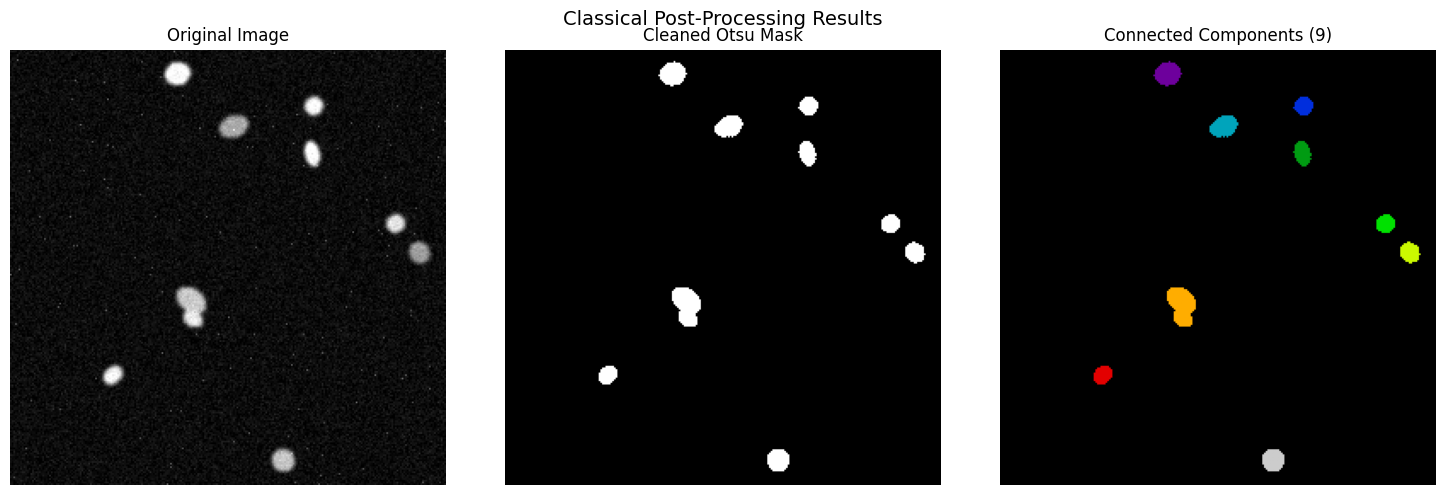

Saved: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\classical_features\classical_postprocessing_results.png


In [44]:
# ============================================================
# CELL 40 — REPRESENTATIVE CLASSICAL RESULTS
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    representative_image,
    cmap="gray"
)

axes[0].set_title(
    "Original Image"
)

axes[0].axis("off")


axes[1].imshow(
    representative_clean_mask,
    cmap="gray"
)

axes[1].set_title(
    "Cleaned Otsu Mask"
)

axes[1].axis("off")


axes[2].imshow(
    representative_labels,
    cmap="nipy_spectral"
)

axes[2].set_title(
    f"Connected Components ({len(representative_features)})"
)

axes[2].axis("off")


plt.suptitle(
    "Classical Post-Processing Results",
    fontsize=14
)

plt.tight_layout()

final_visual_path = os.path.join(
    CLASSICAL_OUTPUT_DIR,
    "classical_postprocessing_results.png"
)

plt.savefig(
    final_visual_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    final_visual_path
)

## 15. Task 2 Completion Check

This final section verifies that the main outputs required for the classical post-processing and numbers-first LLM stage have been generated.

The notebook deliberately keeps classical segmentation, numerical feature extraction and LLM interpretation separate from the U-Net training and hybrid pipeline notebooks.

In [45]:
# ============================================================
# CELL 42 — FINAL NOTEBOOK VERIFICATION
# ============================================================

required_outputs = {
    "Otsu feature table":
        os.path.join(
            CLASSICAL_OUTPUT_DIR,
            "otsu_feature_table.csv"
        ),

    "Otsu image summaries":
        os.path.join(
            CLASSICAL_OUTPUT_DIR,
            "otsu_image_summaries.csv"
        ),

    "Otsu LLM results":
        os.path.join(
            CLASSICAL_OUTPUT_DIR,
            "otsu_llm_results.csv"
        ),

    "Numbers-first example":
        os.path.join(
            CLASSICAL_OUTPUT_DIR,
            "example_numbers_first.json"
        ),

    "Otsu test results":
        os.path.join(
            CLASSICAL_OUTPUT_DIR,
            "otsu_final_summary.csv"
        ),

    "Otsu process visual":
        os.path.join(
            CLASSICAL_OUTPUT_DIR,
            "otsu_segmentation_process.png"
        ),

    "Classical results visual":
        os.path.join(
            CLASSICAL_OUTPUT_DIR,
            "classical_postprocessing_results.png"
        )
}


print("=" * 70)
print("TASK 2 NOTEBOOK — FINAL VERIFICATION")
print("=" * 70)

all_outputs_exist = True

for name, path in required_outputs.items():

    exists = os.path.exists(path)

    print(
        f"{name:<30}:",
        "OK" if exists else "MISSING"
    )

    if not exists:
        all_outputs_exist = False


print("\n" + "=" * 70)

if all_outputs_exist:

    print(
        "TASK 2 CLASSICAL POST-PROCESSING COMPLETE"
    )

else:

    print(
        "Some expected outputs are missing."
    )

print("=" * 70)

TASK 2 NOTEBOOK — FINAL VERIFICATION
Otsu feature table            : OK
Otsu image summaries          : OK
Otsu LLM results              : OK
Numbers-first example         : OK
Otsu test results             : OK
Otsu process visual           : OK
Classical results visual      : OK

TASK 2 CLASSICAL POST-PROCESSING COMPLETE


In [46]:
# ============================================================
# CELL 43 — REPORT-READY RECORD
# ============================================================

report_ready_record = {
    "task": "Task 2 — Classical post-processing",
    "segmentation_method": "Otsu thresholding with morphological cleanup",
    "feature_extraction": "Connected components + regionprops_table",
    "llm_method": "Numbers-first text-only Qwen interpretation",
    "images_evaluated": otsu_summary["images_evaluated"],
    "mean_dice": otsu_summary["mean_dice"],
    "mean_iou": otsu_summary["mean_iou"],
    "mean_precision": otsu_summary["mean_precision"],
    "mean_recall": otsu_summary["mean_recall"],
    "direct_unet_mask_comparison_available": False
}

print("=" * 70)
print("REPORT-READY TASK 2 RECORD")
print("=" * 70)

print(
    json.dumps(
        report_ready_record,
        indent=2
    )
)

report_record_path = os.path.join(
    CLASSICAL_OUTPUT_DIR,
    "task2_report_ready_record.json"
)

with open(
    report_record_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report_ready_record,
        f,
        indent=2
    )

print(
    "\nSaved:",
    report_record_path
)

REPORT-READY TASK 2 RECORD
{
  "task": "Task 2 \u2014 Classical post-processing",
  "segmentation_method": "Otsu thresholding with morphological cleanup",
  "feature_extraction": "Connected components + regionprops_table",
  "llm_method": "Numbers-first text-only Qwen interpretation",
  "images_evaluated": 12,
  "mean_dice": 0.9775505897124698,
  "mean_iou": 0.9561094995174709,
  "mean_precision": 0.9776398240778909,
  "mean_recall": 0.9775030277286519,
  "direct_unet_mask_comparison_available": false
}

Saved: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\classical_features\task2_report_ready_record.json
